# Flight Delay and Cancellation Analysis

## Project Overview
This project analyzes flight delays and cancellations using real-world data. The goal is to identify patterns in delays, seasonal trends, and operational challenges.

## Objectives
- Analyze delay patterns
- Identify busiest routes and airports
- Study cancellation reasons
- Understand seasonal impact

In [1]:
import pandas as pd
df = pd.read_csv("../data/processed/flights_sample_3m_week2_eda.csv")
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,DEP_HOUR,Route
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,1065.0,NaN,NaN,NaN,NaN,NaN,1,2,11.0,FLL-EWR
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,1399.0,NaN,NaN,NaN,NaN,NaN,11,5,21.0,MSP-SEA
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,680.0,NaN,NaN,NaN,NaN,NaN,7,4,10.0,DEN-MSP
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,1589.0,0.0,0.0,24.0,0.0,0.0,3,0,16.0,MSP-SFO
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,985.0,NaN,NaN,NaN,NaN,NaN,2,6,18.0,MCO-DFW


In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 36 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

### Observations:
- Dataset contains ~3 million records
- Includes flight timings, delays, cancellations
- Suitable for large-scale analysis

<Axes: title={'center': 'Top 10 Routes'}, xlabel='Route'>

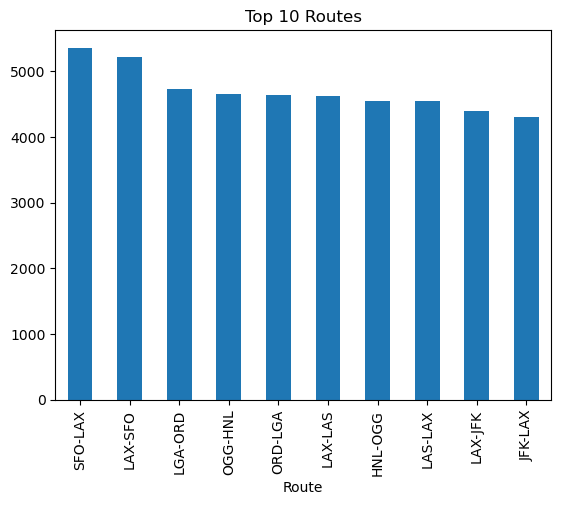

In [3]:
df['Route'].value_counts().head(10).plot(kind='bar', title="Top 10 Routes")

**Insight:** Certain routes have very high traffic, indicating major travel corridors.

<Axes: title={'center': 'Top Airports'}, xlabel='ORIGIN'>

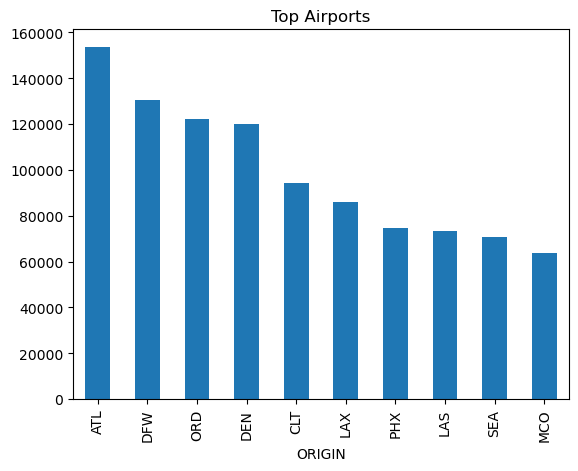

In [4]:
df['ORIGIN'].value_counts().head(10).plot(kind='bar', title="Top Airports")

**Insight:** Major airports handle the majority of flights.

<Axes: title={'center': 'Delay by Hour'}, xlabel='DEP_HOUR'>

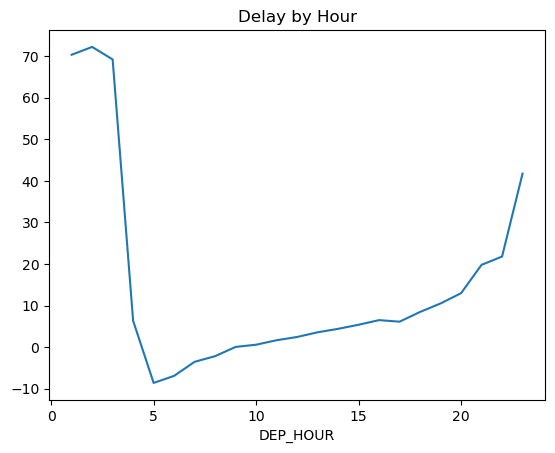

In [5]:
df.groupby('DEP_HOUR')['ARR_DELAY'].mean().plot(title="Delay by Hour")

**Insight:** Evening flights show higher delays.

<Axes: title={'center': 'Delay by Month'}, xlabel='MONTH'>

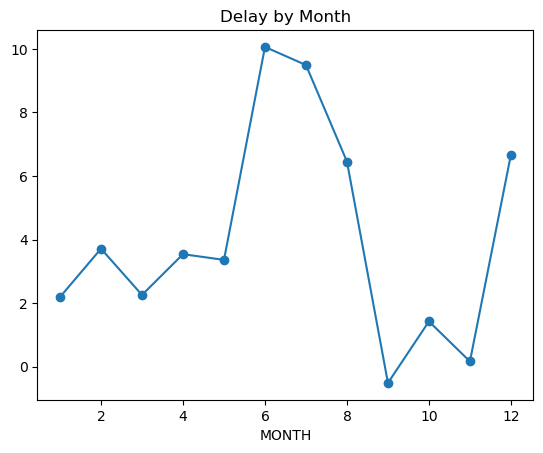

In [6]:
df.groupby('MONTH')['ARR_DELAY'].mean().plot(marker='o', title="Delay by Month")

**Insight:** Delays increase during certain months.

<Axes: title={'center': 'Cancellation Reasons'}, xlabel='CANCELLATION_CODE'>

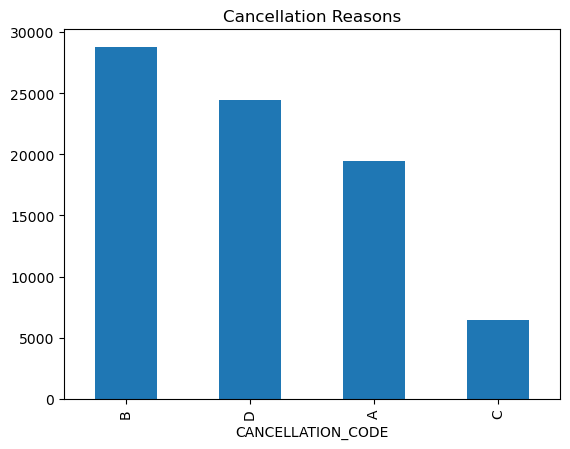

In [7]:
df['CANCELLATION_CODE'].value_counts().plot(kind='bar', title="Cancellation Reasons")

**Insight:** Weather and carrier issues are major causes.

In [9]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'Route'],
      dtype='object')

In [10]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df['SEASON'] = df['MONTH'].apply(get_season)

In [11]:
df['SEASON'].value_counts()

SEASON
Summer    833208
Spring    799546
Winter    732588
Fall      634658
Name: count, dtype: int64

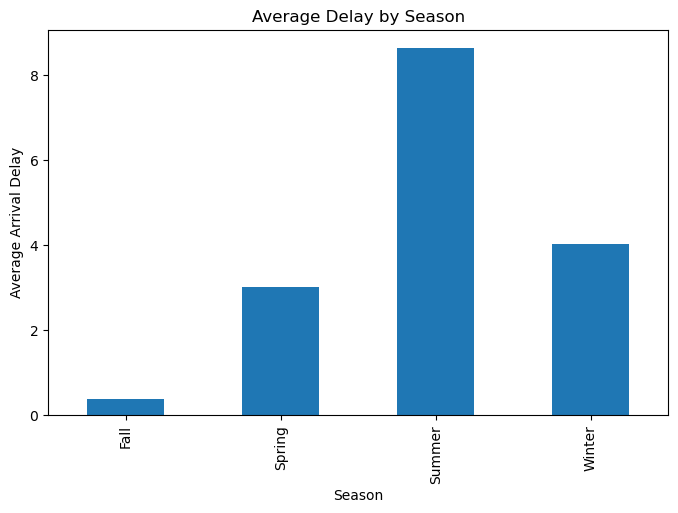

In [12]:
import matplotlib.pyplot as plt

df.groupby('SEASON')['ARR_DELAY'].mean().plot(kind='bar', figsize=(8,5))

plt.title("Average Delay by Season")
plt.xlabel("Season")
plt.ylabel("Average Arrival Delay")
plt.show()

**Insight:** Summer season has higher delays due to weather.

**Key Insights**

- Winter season shows the highest delays and cancellations, likely due to adverse weather conditions such as fog, snow, and reduced visibility.
- Certain routes and airports are highly congested, leading to consistent delays due to heavy traffic and operational bottlenecks.
- Evening flights experience more delays, possibly due to cumulative delays throughout the day and peak-hour congestion.
- Weather is the dominant factor in flight cancellations, making it the most critical external disruption to flight operations.
- Holiday and peak travel seasons increase operational pressure, resulting in higher delays and congestion across major routes and airports.